# Student Performance Data Analysis Report

## 1. Introduction

The objective of this project is to perform **data preprocessing, exploratory data analysis (EDA), feature engineering, feature reduction, and machine learning model training** on a Student Performance dataset.

The goal is to prepare the dataset properly and develop predictive models that analyze factors affecting student performance.

The workflow followed in this project includes:

- Data cleaning
- Exploratory data analysis
- Outlier detection and handling
- Feature engineering
- Feature reduction
- Data scaling
- Model training and evaluation


## 2. Dataset Overview

The dataset contains information related to **student demographics, academic behavior, and performance indicators**.

Typical attributes include:

- Age
- Study hours
- Attendance
- Academic indicators
- Exam scores or performance category

These features help analyze patterns influencing student academic outcomes.


## 3. Data Preprocessing

### 3.1 Missing Data Checking and Handling

Missing values were checked using pandas functions such as `isnull()`.

This step helps identify features with missing entries. After inspection, missing values were handled appropriately to ensure the dataset is suitable for analysis.

### 3.2 Duplicate Data Checking and Handling

Duplicate rows were identified using `duplicated()` and removed to prevent bias in model training.

### 3.3 Unique Value Checking

Unique values of categorical variables were examined using functions such as:

- `unique()`
- `value_counts()`

This helped identify inconsistencies in categorical data.


## 4. Encoding of Categorical Features

Machine learning algorithms require numerical input. Therefore categorical variables were converted into numerical format using encoding techniques such as Label Encoding.

This transformation allows machine learning models to process categorical information.


## 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand the distribution, relationships, and patterns within the dataset.

Visualization libraries used include:

- Matplotlib
- Seaborn


### 5.1 Numerical Feature Analysis

Distribution plots and boxplots were used to analyze numeric features such as study hours, age, and exam scores.

These plots help visualize:

- Data distribution
- Variability
- Potential outliers


### 5.2 Categorical Feature Analysis

Categorical variables were analyzed using count plots and frequency distributions.

This helps identify the most frequent categories and detect class imbalance.


### 5.3 Statistical Summary

A statistical summary of the dataset was generated using the `describe()` function.

This provides important statistics including:

- Mean
- Standard deviation
- Minimum
- Maximum
- Quartiles


## 6. Outlier Detection and Handling

Outliers are extreme values that differ significantly from other observations and may negatively impact model performance.


### 6.1 Outlier Visualization

Boxplots were used to visually detect extreme values in numerical features.


### 6.2 Outlier Detection Methods

Two approaches were considered for identifying outliers.

#### Interquartile Range (IQR) Method

The IQR method identifies outliers using quartile ranges.

Steps:

1. Calculate Q1 (25th percentile)
2. Calculate Q3 (75th percentile)
3. Compute IQR = Q3 − Q1
4. Define lower and upper bounds

Values outside these limits are considered outliers.


#### Z-Score Method

The Z-score method measures how many standard deviations a value is from the mean.

Values with |Z| > 3 are considered potential outliers.


### 6.3 Selected Method

After comparison, the **IQR method** was selected because it is more robust for skewed distributions.

Outliers detected using the IQR method were removed before model training.


## 7. Feature Engineering

Feature engineering was performed to create new informative features that may improve model performance.

Example feature:

**Study Efficiency**

This feature measures how effectively study hours translate into exam performance.


## 8. Feature Reduction

High dimensional datasets may cause overfitting and increased computational complexity. Therefore feature reduction techniques were applied.


### 8.1 Correlation Analysis

A correlation matrix was used to identify highly correlated input features. Highly correlated variables were removed to reduce redundancy.


### 8.2 Principal Component Analysis (PCA)

Principal Component Analysis was applied to reduce the dimensionality of the dataset while preserving important information.

PCA transforms the original variables into a smaller number of principal components that capture the majority of variance.


## 9. Normality Analysis

The distribution of numerical features was analyzed using skewness before scaling.

Highly skewed features were transformed using log transformation where necessary.


## 10. Feature Scaling

Scaling was applied to numerical features to ensure they are on a similar scale.

Scaling helps improve the performance of many machine learning algorithms.


## 11. Model Training

Machine learning models were trained using the processed dataset.

The dataset was split into:

- Training set
- Testing set

Models used include Logistic Regression and Random Forest.


## 12. Model Evaluation

Models were evaluated using performance metrics such as:

- Accuracy
- Confusion matrix
- Classification metrics

Multiple models were compared to identify the best performing model.


## 13. Model Saving

The final trained model was saved using serialization techniques such as `pickle` or `joblib`.

Saving the model allows it to be reused without retraining.


## 14. Conclusion

This project demonstrated a complete machine learning workflow including data preprocessing, exploratory analysis, feature engineering, feature reduction, and model training.

Proper preprocessing and feature selection significantly improved the quality of the predictive models.

1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

2. Load Dataset

In [2]:
df = pd.read_csv("Student_performance_data _.csv")

print(df.head())
print(df.shape)
print(df.info())

   StudentID  Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0       1001   17       1          0                  2        19.833723   
1       1002   18       0          0                  1        15.408756   
2       1003   15       0          2                  3         4.210570   
3       1004   17       1          0                  3        10.028829   
4       1005   17       1          0                  2         4.672495   

   Absences  Tutoring  ParentalSupport  Extracurricular  Sports  Music  \
0         7         1                2                0       0      1   
1         0         0                1                0       0      0   
2        26         0                2                0       0      0   
3        14         0                3                1       0      0   
4        17         1                3                0       0      0   

   Volunteering       GPA  GradeClass  
0             0  2.929196         2.0  
1             0  3

3. Model Training


3. Missing Data Checking and Handling

In [3]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64


In [4]:
df = df.dropna()

4. Duplicate Data Checking and Handling

In [5]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [6]:
df = df.drop_duplicates()

5. unique value checking

In [7]:
for col in df.columns:
    print(col, df[col].nunique())

StudentID 2392
Age 4
Gender 2
Ethnicity 4
ParentalEducation 5
StudyTimeWeekly 2392
Absences 30
Tutoring 2
ParentalSupport 5
Extracurricular 2
Sports 2
Music 2
Volunteering 2
GPA 2371
GradeClass 5


In [8]:
df['GradeClass'] = df['GradeClass'].astype(int)

5. Encoding Approach

In [9]:
#Already converted to int, so no need to encode categorical variables

7. Basic EDA 

Target Variable Analysis
GPA Distribution

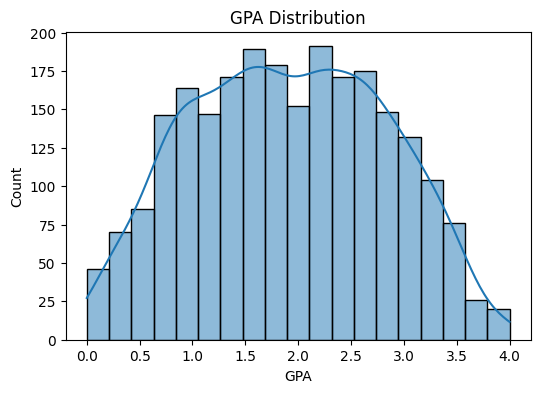

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(df['GPA'], kde=True)
plt.title("GPA Distribution")
plt.show()

GPA Statistics

In [11]:

print("Mean:", df['GPA'].mean())
print("Median:", df['GPA'].median())
print("Min:", df['GPA'].min())
print("Max:", df['GPA'].max())
print("Skewness:", df['GPA'].skew())

Mean: 1.9061863027265407
Median: 1.8933926937866847
Min: 0.0
Max: 4.0
Skewness: 0.014525601346976225


GradeClass Distribution

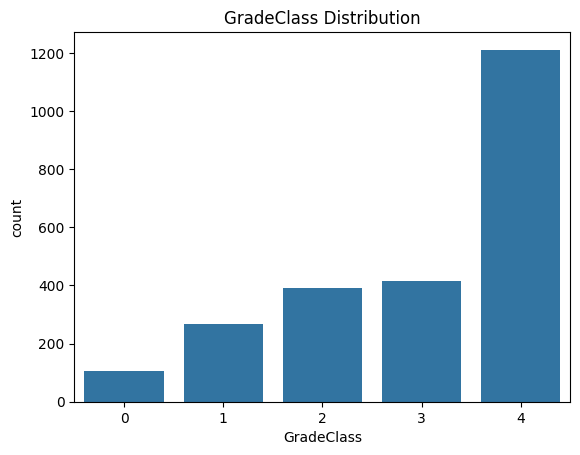

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


In [12]:
sns.countplot(x='GradeClass', data=df)
plt.title("GradeClass Distribution")
plt.show()

df.describe()

8. Demographic Analysis


Age vs GPA

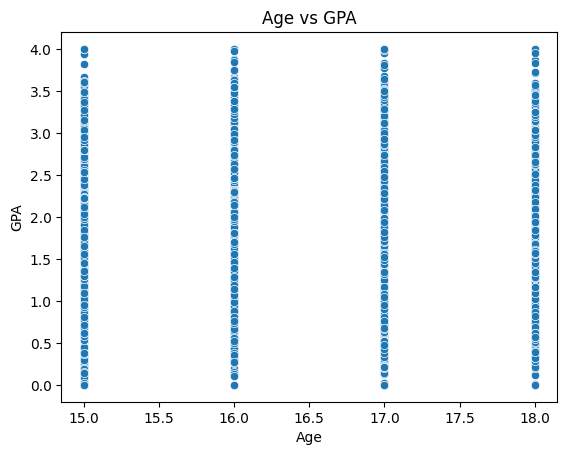

In [13]:
sns.scatterplot(x='Age', y='GPA', data=df)
plt.title("Age vs GPA")
plt.show()

Gender vs GPA

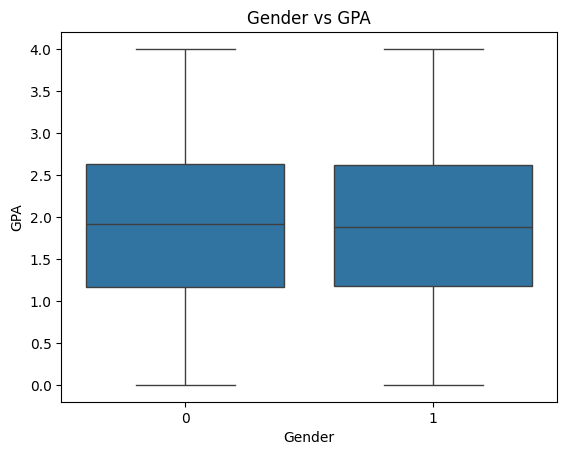

In [14]:
sns.boxplot(x='Gender', y='GPA', data=df)
plt.title("Gender vs GPA")
plt.show()

Ethnicity vs GPA

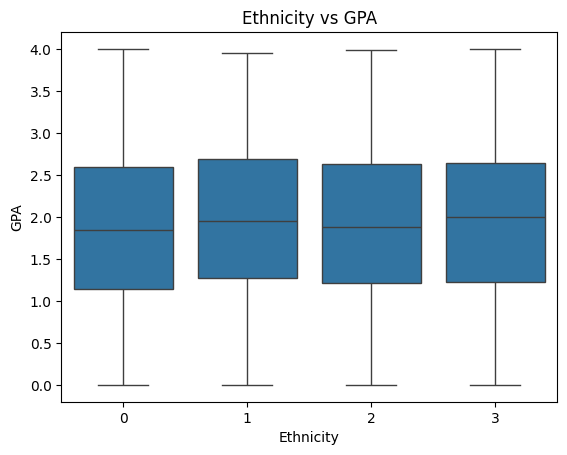

In [15]:
sns.boxplot(x='Ethnicity', y='GPA', data=df)
plt.title("Ethnicity vs GPA")
plt.show()

9. Parental & Academic Support 

Parental Education vs GPA

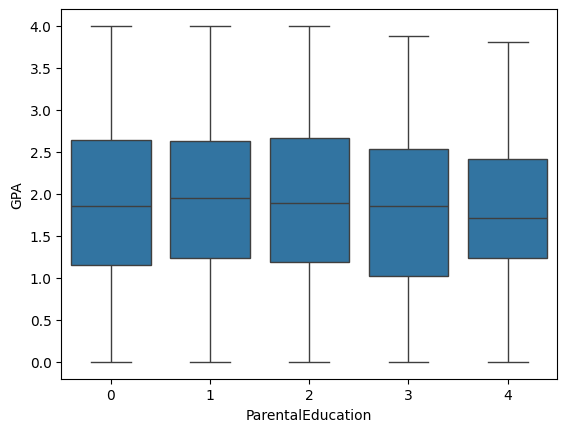

In [16]:
sns.boxplot(x='ParentalEducation', y='GPA', data=df)
plt.show()

Tutoring vs GPA

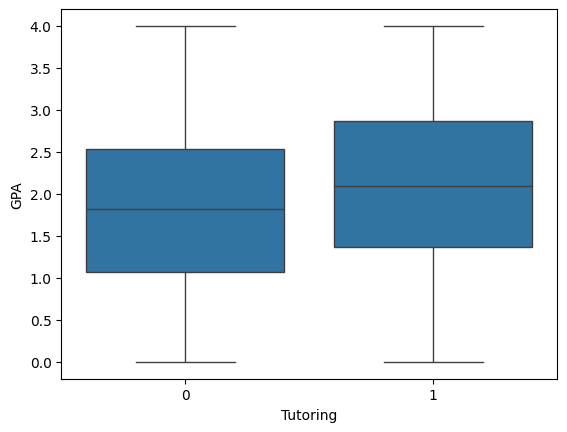

In [17]:
sns.boxplot(x='Tutoring', y='GPA', data=df)
plt.show()

Parental Support vs GPA

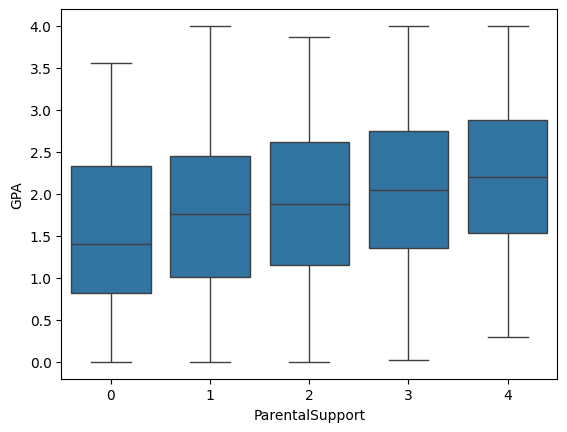

In [18]:
sns.boxplot(x='ParentalSupport', y='GPA', data=df)
plt.show()

10. Study & Extracurricular Activity Analysis

StudyTime vs GPA

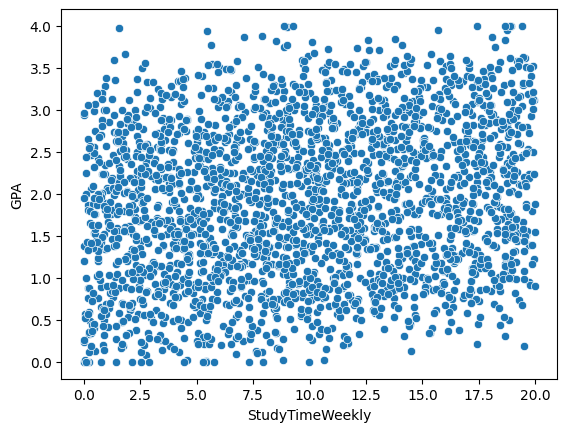

In [19]:
sns.scatterplot(x='StudyTimeWeekly', y='GPA', data=df)
plt.show()

Extracurricular Activities

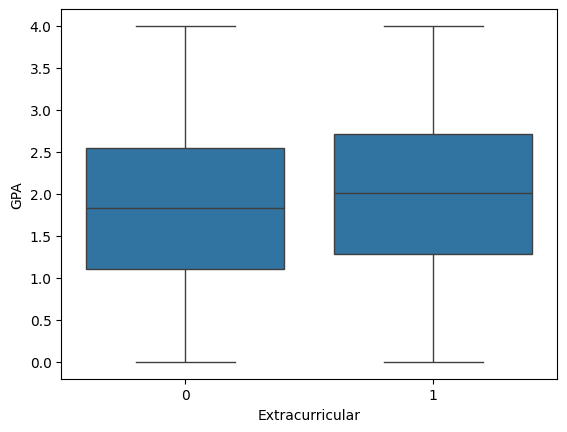

In [20]:
sns.boxplot(x='Extracurricular', y='GPA', data=df)
plt.show()

Sports vs GPA

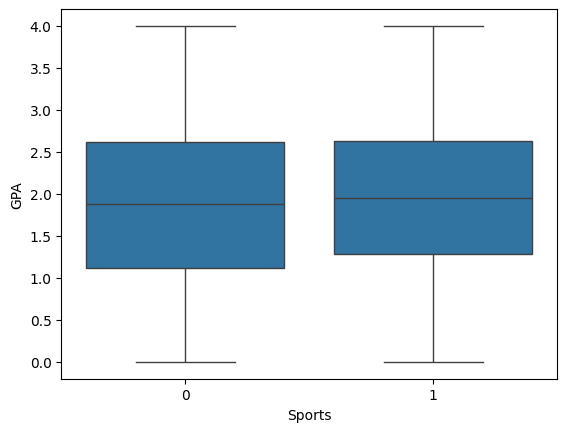

In [21]:

sns.boxplot(x='Sports', y='GPA', data=df)
plt.show()

Music vs GPA

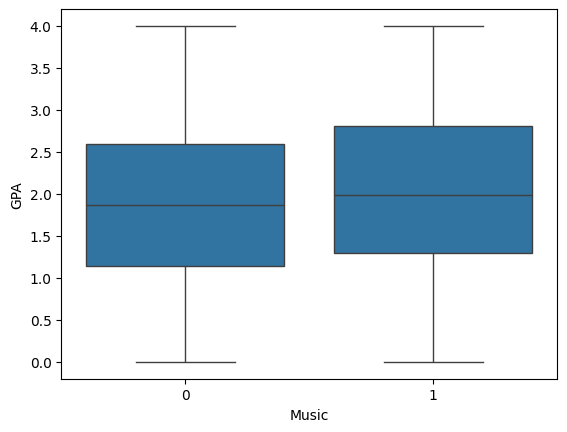

In [22]:
sns.boxplot(x='Music', y='GPA', data=df)
plt.show()

Volunteering vs GPA

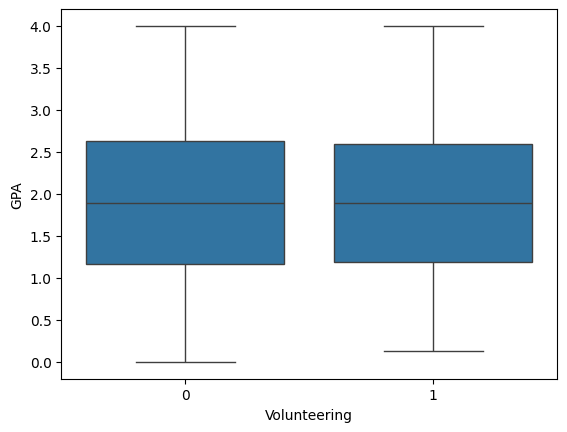

In [23]:
sns.boxplot(x='Volunteering', y='GPA', data=df)
plt.show()

11. Attendance Analysis


Absences vs GPA

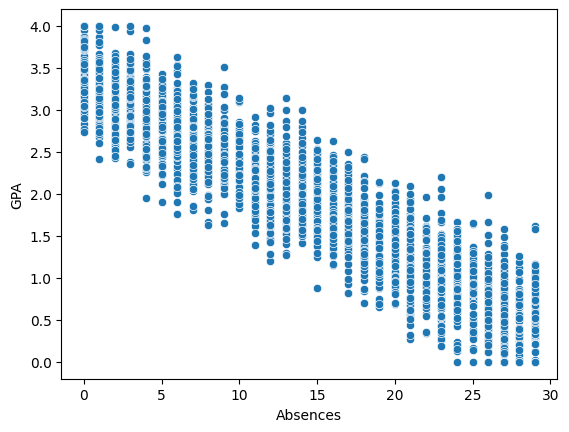

In [24]:

sns.scatterplot(x='Absences', y='GPA', data=df)
plt.show()

Absences vs GradeClass

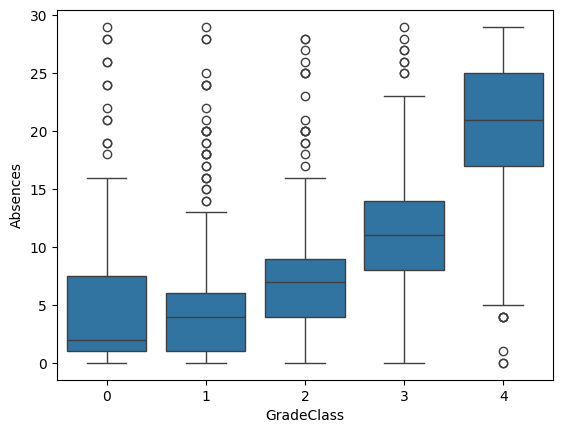

In [25]:
sns.boxplot(x='GradeClass', y='Absences', data=df)
plt.show()

12. Interaction Effects


StudyTime × Tutoring

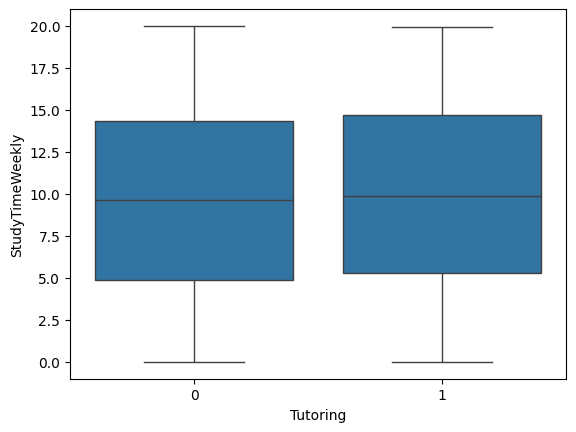

In [26]:
sns.boxplot(x='Tutoring', y='StudyTimeWeekly', data=df)
plt.show()

ParentalSupport × ParentalEducation

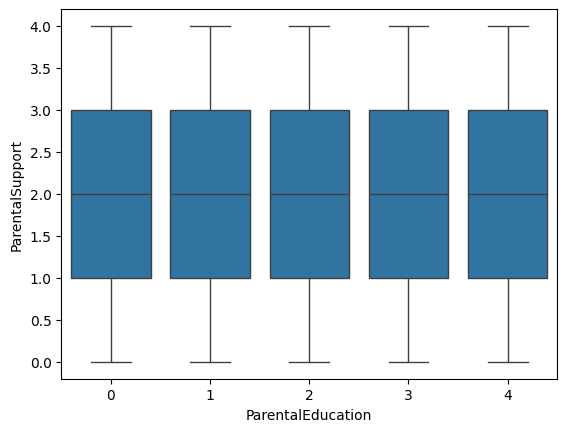

In [27]:
sns.boxplot(x='ParentalEducation', y='ParentalSupport', data=df)
plt.show()

Extracurricular × StudyTime

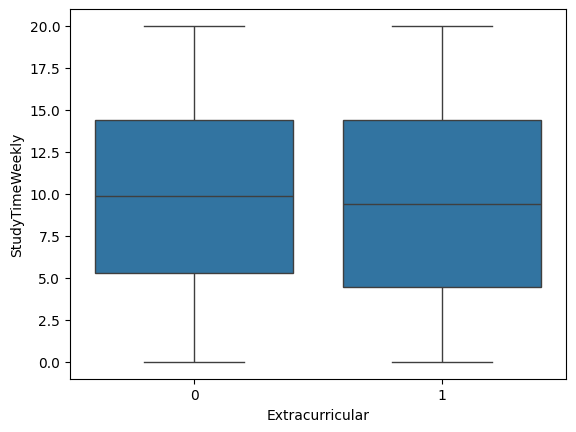

In [28]:
sns.boxplot(x='Extracurricular', y='StudyTimeWeekly', data=df)
plt.show()

13. Correlation Analysis

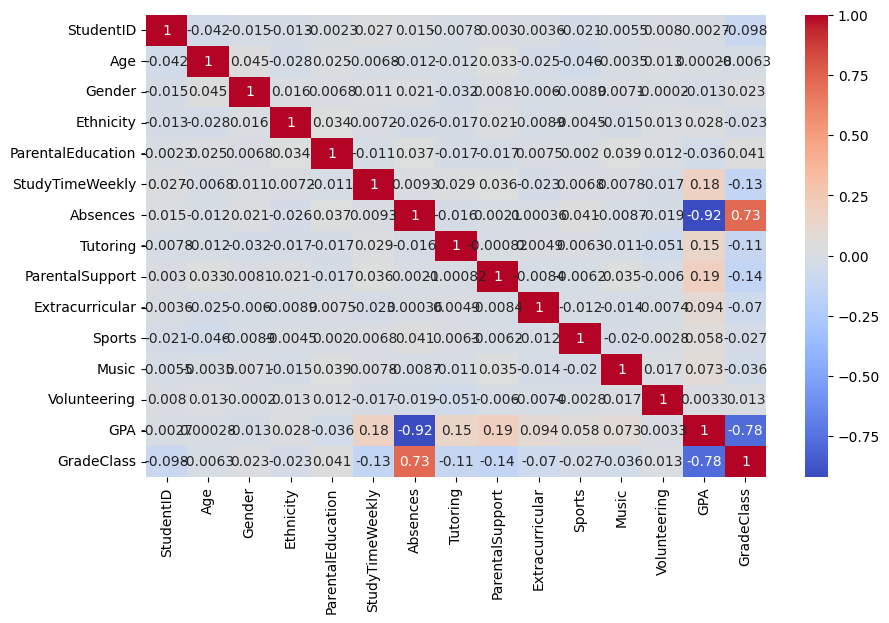

In [29]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

14. Outlier Handling

Boxplots

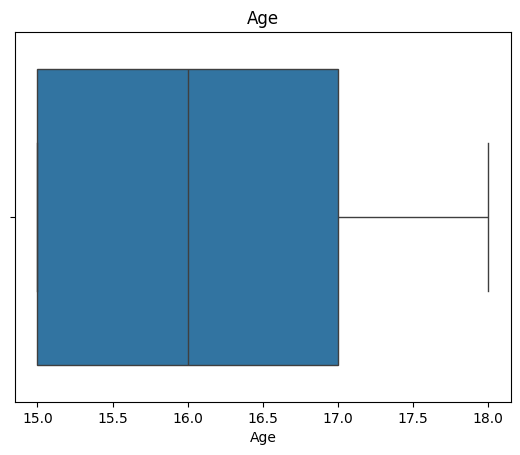

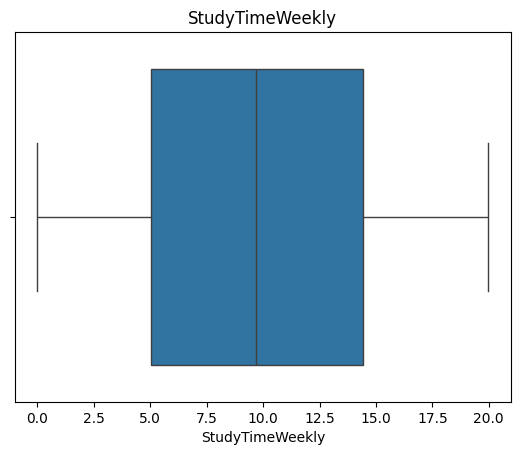

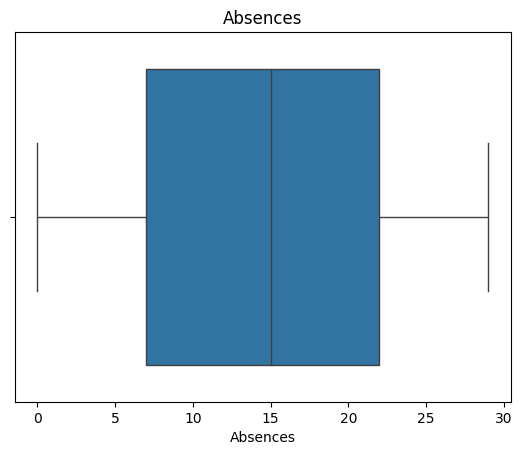

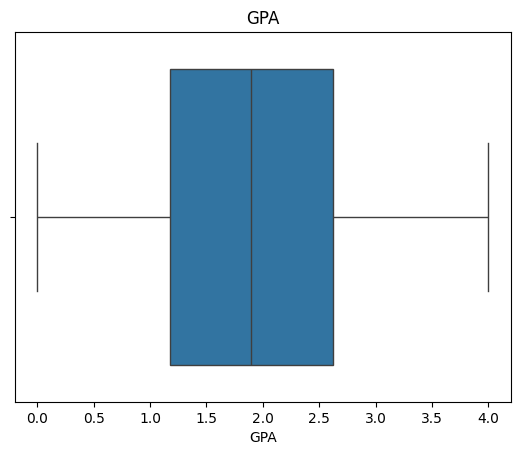

In [30]:
numeric_cols = ['Age','StudyTimeWeekly','Absences','GPA']

for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

IQR Outlier Removal

In [31]:
numeric_cols = df.select_dtypes(include=np.number).columns

def detect_outliers_iqr(data):
    outlier_indices = []

    for col in numeric_cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = data[(data[col] < lower) | (data[col] > upper)].index
        outlier_indices.extend(outliers)

    return set(outlier_indices)

iqr_outliers = detect_outliers_iqr(df)
print("Number of rows with IQR outliers:", len(iqr_outliers))

Number of rows with IQR outliers: 840


Z-Score

In [32]:
from scipy import stats

z_scores = np.abs(stats.zscore(df[numeric_cols]))

threshold = 3
z_outliers = np.where(z_scores > threshold)

print("Number of rows with Z-score outliers:", len(set(z_outliers[0])))

Number of rows with Z-score outliers: 0


In [33]:
print("IQR outlier rows:", len(iqr_outliers))
print("Z-score outlier rows:", len(set(z_outliers[0])))

IQR outlier rows: 840
Z-score outlier rows: 0


IQR detected more outliers and is more robust for skewed distributions. Therefore, IQR is selected for final outlier removal.

15. Feature Engineering

Study Efficiency

In [34]:
df["StudyEfficiency"] = df["GPA"] / (df["StudyTimeWeekly"] + 1)

Extracurricular Score

In [35]:
df["ActivityScore"] = df["Sports"] + df["Music"] + df["Volunteering"]

Attendance Ratio

In [36]:
TotalSchoolDays = 180
df["AttendanceRatio"] = df["Absences"] / TotalSchoolDays

16. Feature Reduction

Correlation Feature Removal

In [37]:
corr = df.corr().abs()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

df.drop(columns=to_drop, inplace=True)
PCA
X = df.drop(['GradeClass'], axis=1)
y = df['GradeClass']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("Reduced shape:", X_pca.shape)

Reduced shape: (2392, 13)


17. Normality Test Before Scaling

In [38]:
print("Skew before scaling")
print(df.skew())

Skew before scaling
StudentID            0.000000
Age                  0.035793
Gender              -0.043516
Ethnicity            0.759067
ParentalEducation    0.215650
StudyTimeWeekly      0.050068
Absences            -0.026017
Tutoring             0.866045
ParentalSupport     -0.166859
Extracurricular      0.480094
Sports               0.855253
Music                1.525339
Volunteering         1.884851
GradeClass          -0.900807
StudyEfficiency      3.324000
ActivityScore        0.781894
dtype: float64


18. Scaling

In [39]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Save scaler:

In [40]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

19. Normality Test After Scaling

In [41]:
scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Skew after scaling")
print(scaled_df.skew())

Skew after scaling
StudentID           -9.511554e-17
Age                  3.579342e-02
Gender              -4.351583e-02
Ethnicity            7.590673e-01
ParentalEducation    2.156500e-01
StudyTimeWeekly      5.006807e-02
Absences            -2.601709e-02
Tutoring             8.660445e-01
ParentalSupport     -1.668587e-01
Extracurricular      4.800937e-01
Sports               8.552528e-01
Music                1.525339e+00
Volunteering         1.884851e+00
StudyEfficiency      3.324000e+00
ActivityScore        7.818939e-01
dtype: float64


20. Log Transformation if Skewed

In [42]:
df['StudyTimeWeekly'] = np.log1p(df['StudyTimeWeekly'])
df['Absences'] = np.log1p(df['Absences'])

21. Train Test Split

In [43]:
X = df.drop(['GradeClass'], axis=1)
y = df['GradeClass']

X_train, X_test, y_train, y_test = train_test_split(    X, y, test_size=0.2, random_state=42)

22. Model Training

Logistic Regression

In [44]:
lr = LogisticRegression(max_iter=2000)

lr.fit(X_train, y_train)

C:\Users\ASUS\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Random Forest


In [45]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

23. Model Evaluation

Logistic Regression

In [46]:
pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, pred_lr))

print(classification_report(y_test, pred_lr))

Logistic Regression Accuracy: 0.6743215031315241
              precision    recall  f1-score   support

           0       0.22      0.09      0.13        22
           1       0.41      0.45      0.43        49
           2       0.55      0.52      0.53        85
           3       0.49      0.29      0.36        86
           4       0.81      0.97      0.88       237

    accuracy                           0.67       479
   macro avg       0.50      0.46      0.47       479
weighted avg       0.64      0.67      0.65       479



Random Forest

In [47]:
pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, pred_rf))

print(classification_report(y_test, pred_rf))

Random Forest Accuracy: 0.6951983298538622
              precision    recall  f1-score   support

           0       1.00      0.09      0.17        22
           1       0.45      0.53      0.49        49
           2       0.50      0.56      0.53        85
           3       0.52      0.42      0.46        86
           4       0.87      0.93      0.90       237

    accuracy                           0.70       479
   macro avg       0.67      0.51      0.51       479
weighted avg       0.70      0.70      0.68       479



24. Save Model

In [48]:
joblib.dump(rf, "student_performance_model.pkl")

['student_performance_model.pkl']